# Vision-Based Saliency Prediction

*Note: If you do not have the dataset downloaded yet, you will not be able to train the models. You can easily retrieve the data by running `download_data.ipynb` first.*

### Setup
Importing libraries and setting up directories.

In [30]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from train import main as train
from train import load_checkpoint, find_latest_checkpoint
from config import get_config
from models import build_model
from data import create_dataloaders

# configuration flags
SAVE_PLOTS = True
PLOT_DIR = "plots"
CHECKPOINT_DIR = "checkpoints"
HISTORY_DIR = "history"

for d in [PLOT_DIR, CHECKPOINT_DIR, HISTORY_DIR]:
    os.makedirs(d, exist_ok=True)

### Training
Run the training loop for the selected experiments. History will be saved to disk so you can plot later without retraining.

In [15]:
experiments = ["transformer_combined"] # e.g., ["baseline", "multiscale", "transformer"]

# Dictionary to store history in memory
all_histories = {}

for name in experiments:
    print(f"\n{'='*20} Running Experiment: {name} {'='*20}")
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Train the model
    model, history = train(name)
    all_histories[name] = history
    
    # Save history to disk
    history_path = os.path.join(HISTORY_DIR, f"{name}_history_{timestamp}.json")
    with open(history_path, 'w') as f:
        json.dump(history, f)
    print(f"Saved history to {history_path}")



==================== Running Experiment: transformer_combined ====================
Using device: cuda
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /home/ronco/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:15<00:00, 7.42MB/s] 


Early stopping: monitor=val_loss, patience=2, min_delta=0.0

--- Epoch 1/20 ---


Validating: 100%|██████████| 157/157 [00:28<00:00,  5.43it/s]


Train Loss: 0.2980 | Val Loss: 0.0652 | PCC: 0.8372 | JSS: 0.8672 | MSE: 0.0788 | NSS: 0.6685 | AUC_Judd: 0.9373
Saved new best model to checkpoints/best_model_transformer_combined_20260719_163815.pth

--- Epoch 2/20 ---


...

Train Loss: -0.3386 | Val Loss: -0.2540 | PCC: 0.9024 | JSS: 0.9566 | MSE: 0.0073 | NSS: 0.5500 | AUC_Judd: 0.9611
Saved new best model to checkpoints/best_model_transformer_combined_20260719_163815.pth

--- Epoch 10/20 ---


Validating: 100%|██████████| 157/157 [00:28<00:00,  5.44it/s]


Train Loss: -0.3477 | Val Loss: -0.2382 | PCC: 0.8988 | JSS: 0.9559 | MSE: 0.0077 | NSS: 0.5298 | AUC_Judd: 0.9604
No improvement for 1/2 epoch(s) (best val loss: -0.2540)

--- Epoch 11/20 ---


Validating: 100%|██████████| 157/157 [00:29<00:00,  5.40it/s]

Train Loss: -0.3543 | Val Loss: -0.2438 | PCC: 0.9000 | JSS: 0.9561 | MSE: 0.0081 | NSS: 0.5390 | AUC_Judd: 0.9612
No improvement for 2/2 epoch(s) (best val loss: -0.2540)
Early stopping triggered after epoch 11: val_loss did not improve for 2 consecutive epochs.
Restored best weights (val loss: -0.2540)
Saved training history to history/transformer_combined_20260719_163815.json
Saved history to history/transformer_combined_history_20260719_163815.json


### Plotting Metrics
Load histories and plot the training and validation curves.

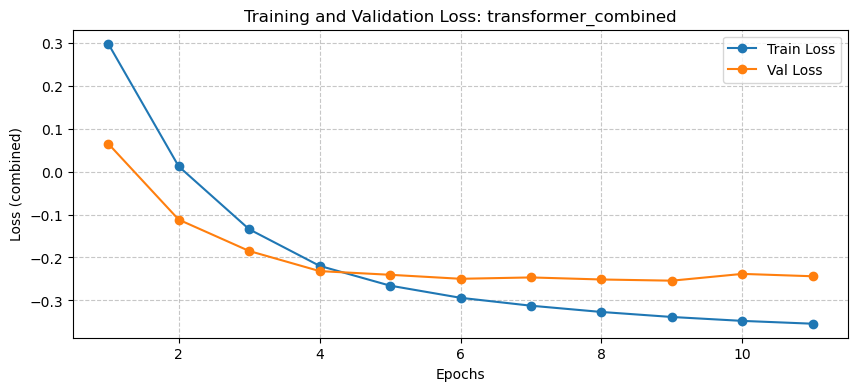

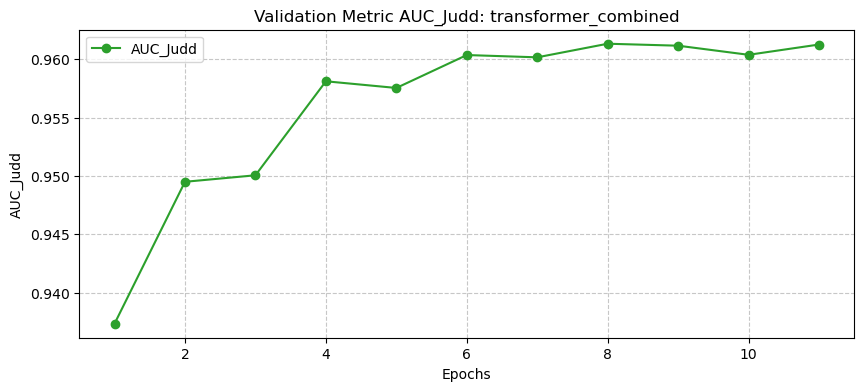

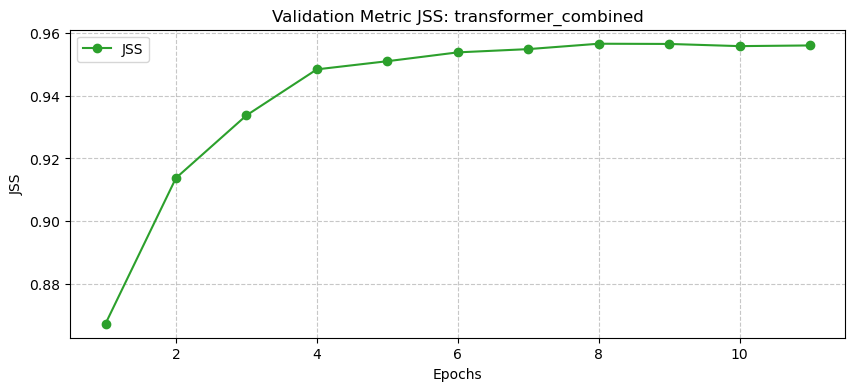

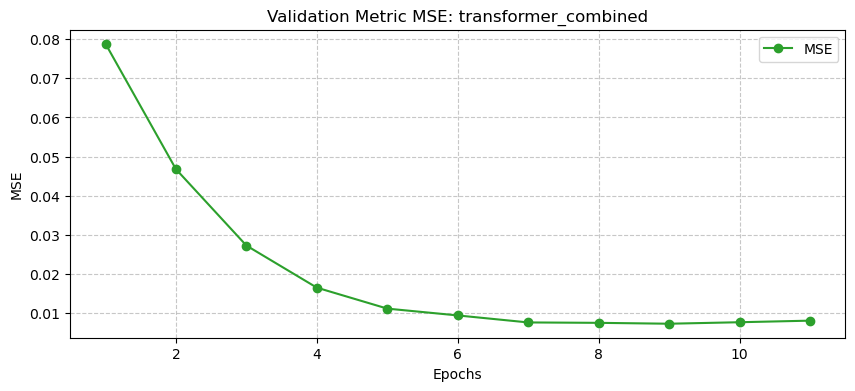

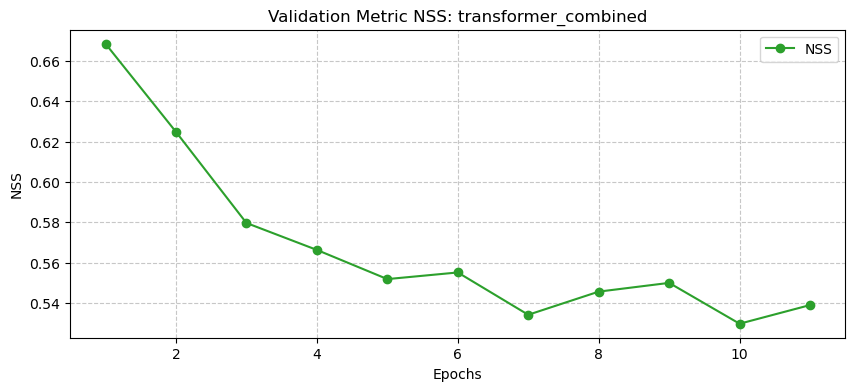

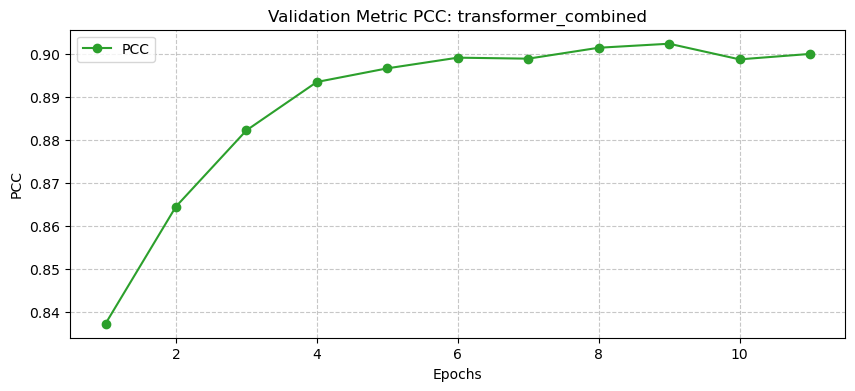

In [18]:
# You can load history from disk if you skipped the training cell
# Example: 
# with open('history/baseline_history_...json', 'r') as f:
#     all_histories['baseline'] = json.load(f)

for name, history in all_histories.items():
    config = get_config(name)
    loss_name = config.loss.name
    
    train_losses = history["train_losses"]
    val_results = history["val_losses"]
    val_loss = [epoch_res["val_loss"] for epoch_res in val_results]
    
    # plot train and val loss
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o', color='#1f77b4')
    plt.plot(range(1, len(val_loss) + 1), val_loss, label='Val Loss', marker='o', color='#ff7f0e')
    plt.xlabel('Epochs')
    plt.ylabel(f'Loss ({loss_name})')
    plt.title(f'Training and Validation Loss: {name}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    if SAVE_PLOTS:
        plt.savefig(os.path.join(PLOT_DIR, f"{name}_loss_plot.png"), bbox_inches='tight')
    plt.show()
    
    # plot other metrics
    all_metrics = set()
    for epoch_res in val_results:
        all_metrics.update([k for k in epoch_res.keys() if k != "val_loss"])
    all_metrics = sorted(list(all_metrics))
    
    for metric in all_metrics:
        metric_vals = [epoch_res[metric] for epoch_res in val_results if metric in epoch_res]
        
        plt.figure(figsize=(10, 4))
        plt.plot(range(1, len(metric_vals) + 1), metric_vals, label=metric, marker='o', color='#2ca02c')
        plt.xlabel('Epochs')
        plt.ylabel(metric)
        plt.title(f'Validation Metric {metric}: {name}')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        if SAVE_PLOTS:
            plt.savefig(os.path.join(PLOT_DIR, f"{name}_{metric}_plot.png"), bbox_inches='tight')
        plt.show()


### Inference & Visualization
Load a trained model checkpoint and visualize predictions on the validation set.

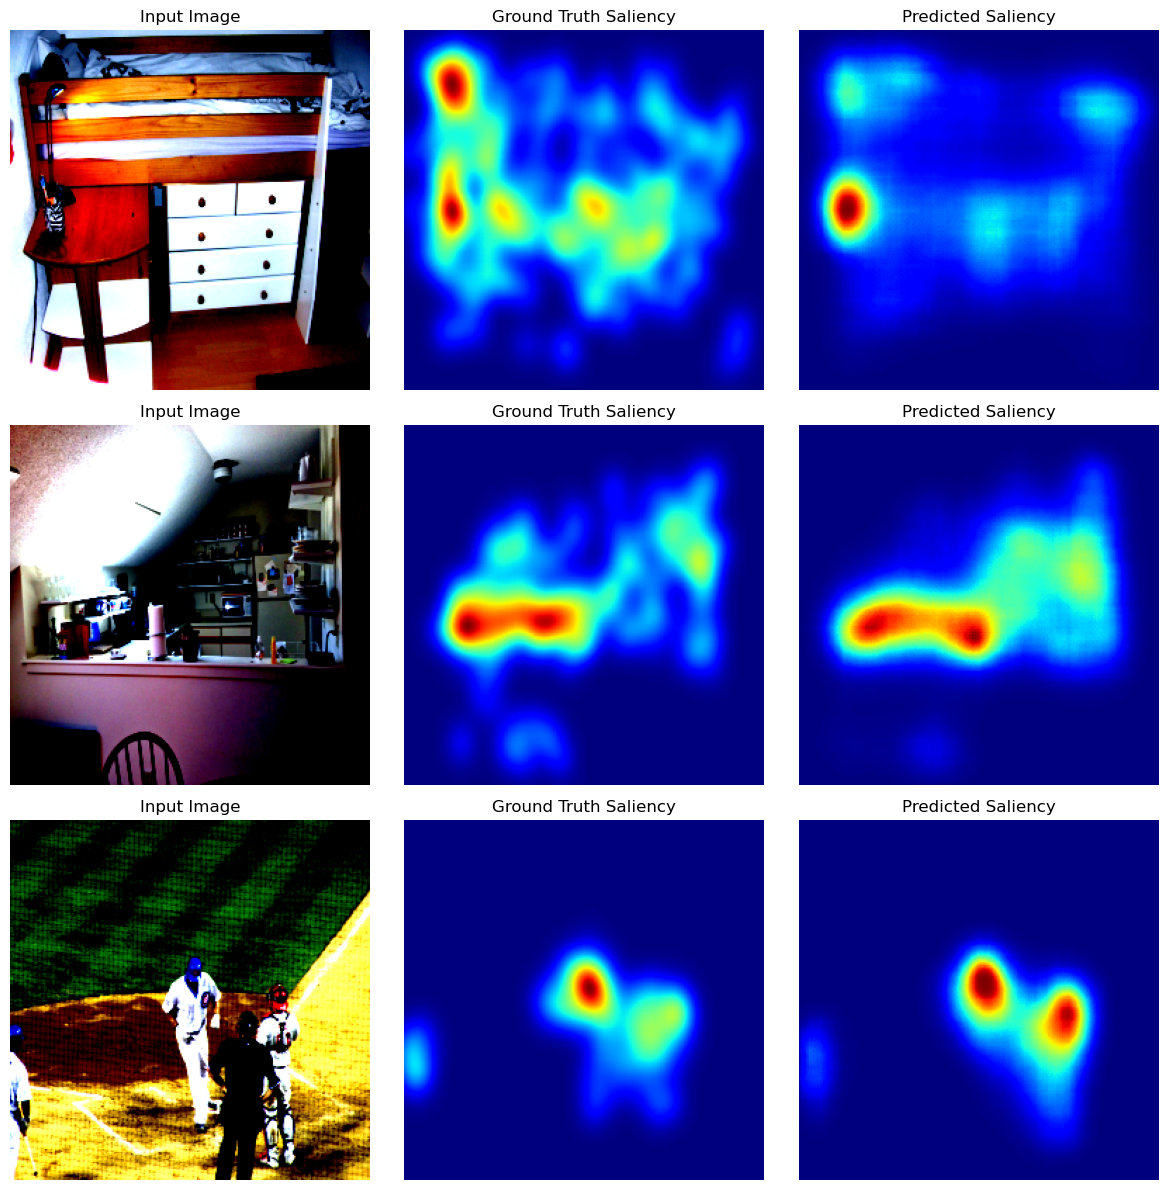

In [38]:
# Pick the experiment and checkpoint to load
EXPERIMENT = "transformer_combined"
CKPT_PATH = None          # None -> newest matching checkpoint in checkpoints/

if CKPT_PATH is None:
    # NOT a plain glob: "best_model_multiscale_*" would also match
    # "best_model_multiscale_skip_*" and load the wrong model's weights
    CKPT_PATH = find_latest_checkpoint(EXPERIMENT)

if not (CKPT_PATH and os.path.exists(CKPT_PATH)):
    print("Please specify a valid checkpoint_path to run inference.")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    config = get_config(EXPERIMENT)
    
    # Build model and load weights
    model = build_model(config.model).to(device)
    epoch, best_val_loss = load_checkpoint(CKPT_PATH, model, device=device)
    model.eval()
    
    # Get dataloaders
    _, val_loader = create_dataloaders(config)
    
    # Fetch a single batch
    images, gts = next(iter(val_loader))
    images, gts = images.to(device), gts.to(device)
    
    with torch.no_grad():
        preds = model(images)
        
    # Move to CPU for plotting
    images = images.cpu().numpy()
    gts = gts.cpu().numpy()
    preds = preds.cpu().numpy()
    
    # Visualize the first 3 images in the batch
    num_to_show = min(3, images.shape[0])
    fig, axes = plt.subplots(num_to_show, 3, figsize=(12, 4 * num_to_show))
    
    for i in range(num_to_show):
        # Denormalize image if necessary (assuming standard ImageNet norm or [0,1] range)
        # Adjust this depending on your data.py transformations
        img = np.transpose(images[i], (1, 2, 0))
        img = np.clip(img, 0, 1) # simple clip, update if using mean/std normalization
        
        gt_map = gts[i][0]
        pred_map = preds[i][0]
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(gt_map, cmap='jet')
        axes[i, 1].set_title("Ground Truth Saliency")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_map, cmap='jet')
        axes[i, 2].set_title("Predicted Saliency")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    if SAVE_PLOTS:
        plt.savefig(os.path.join(PLOT_DIR, f"{EXPERIMENT}_inference.png"), bbox_inches='tight')
    plt.show()
